# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


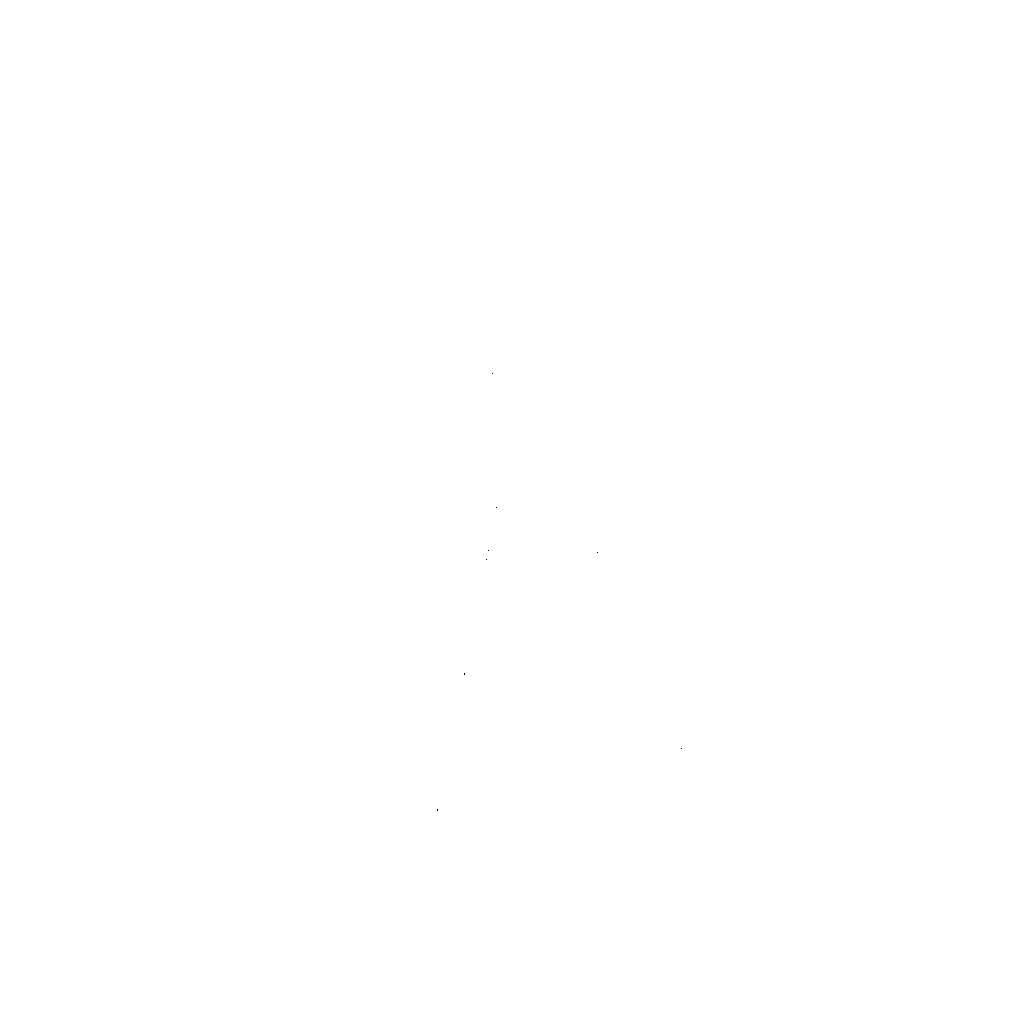

Threshold value: 50


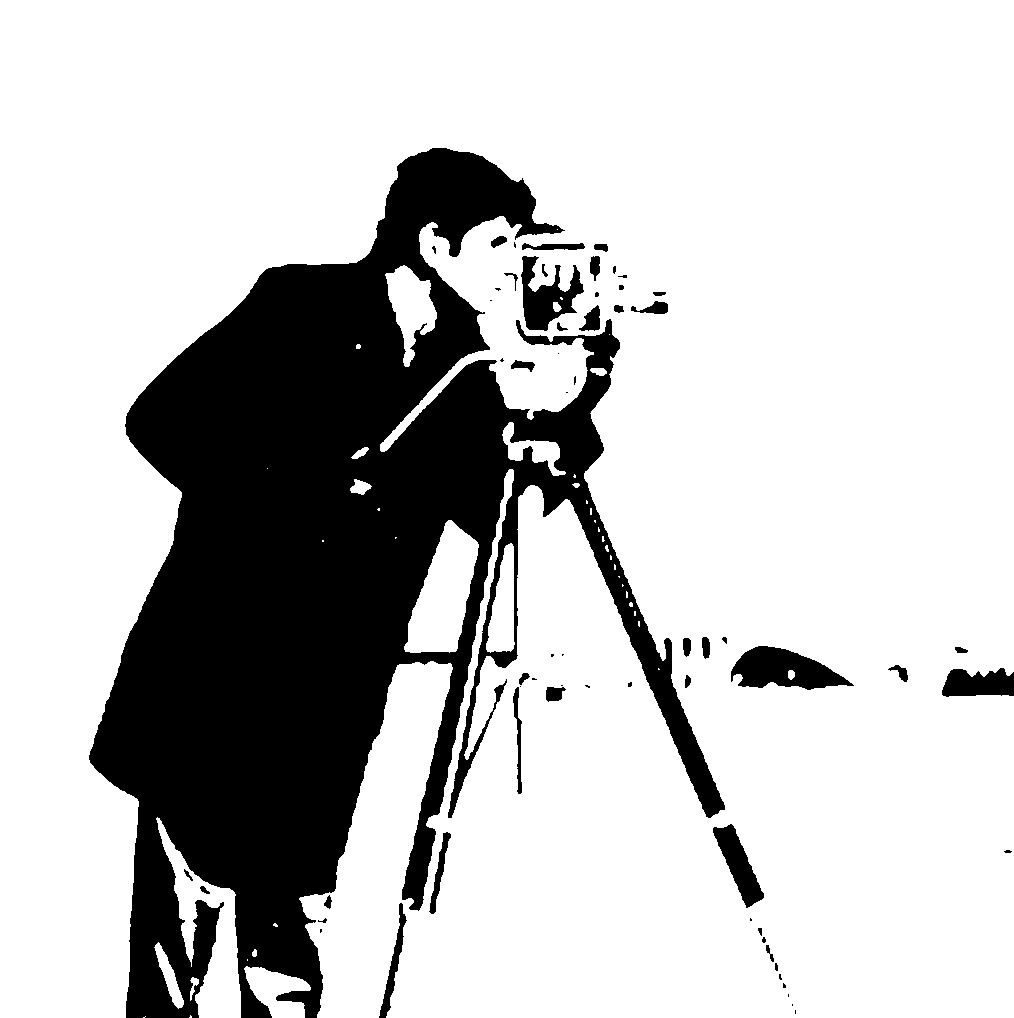

Threshold value: 100


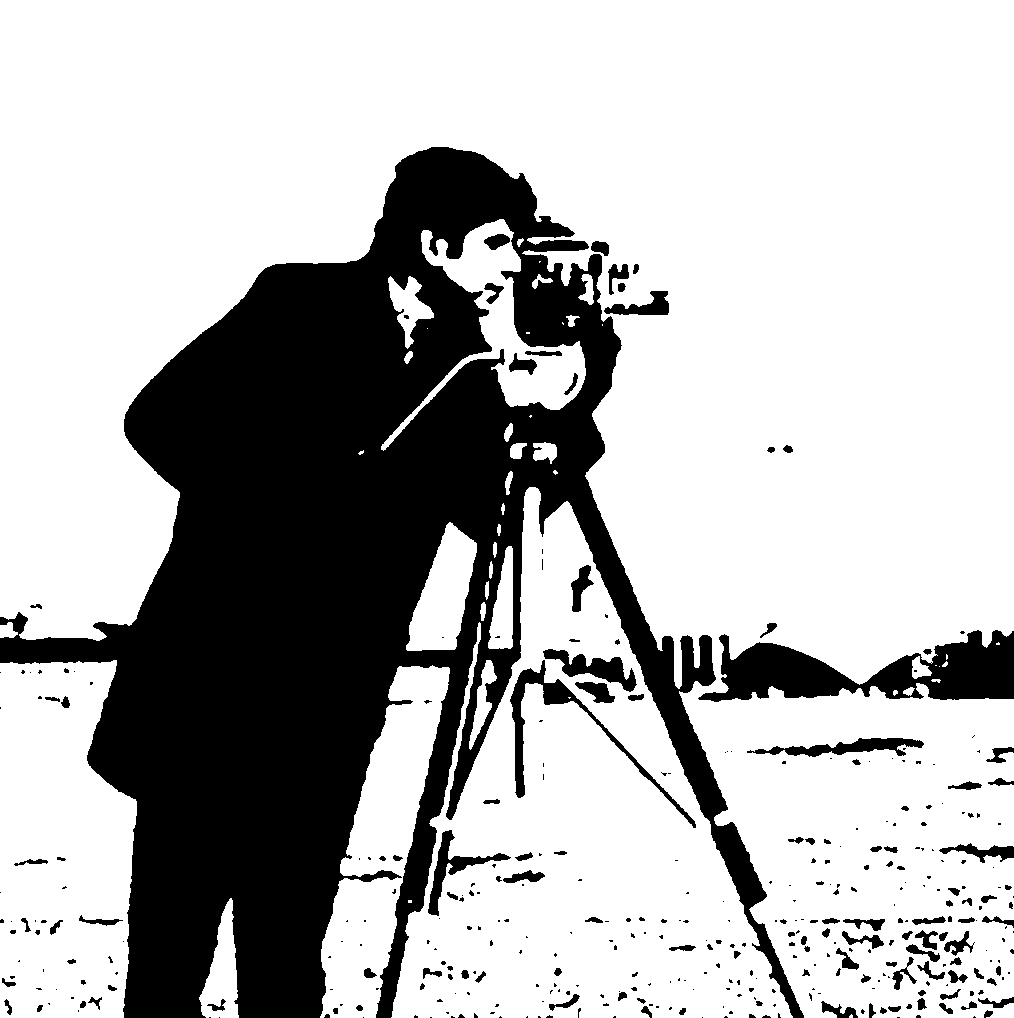

Threshold value: 150


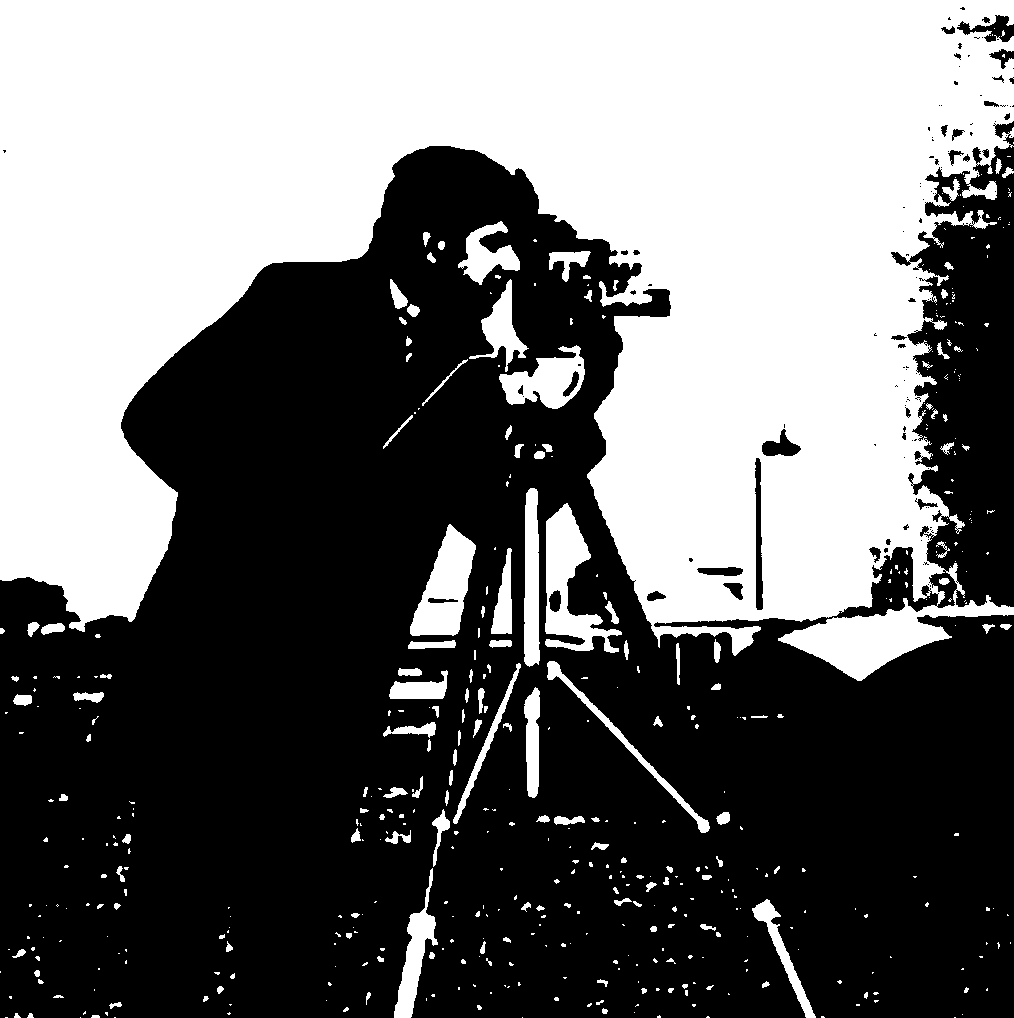

Threshold value: 200


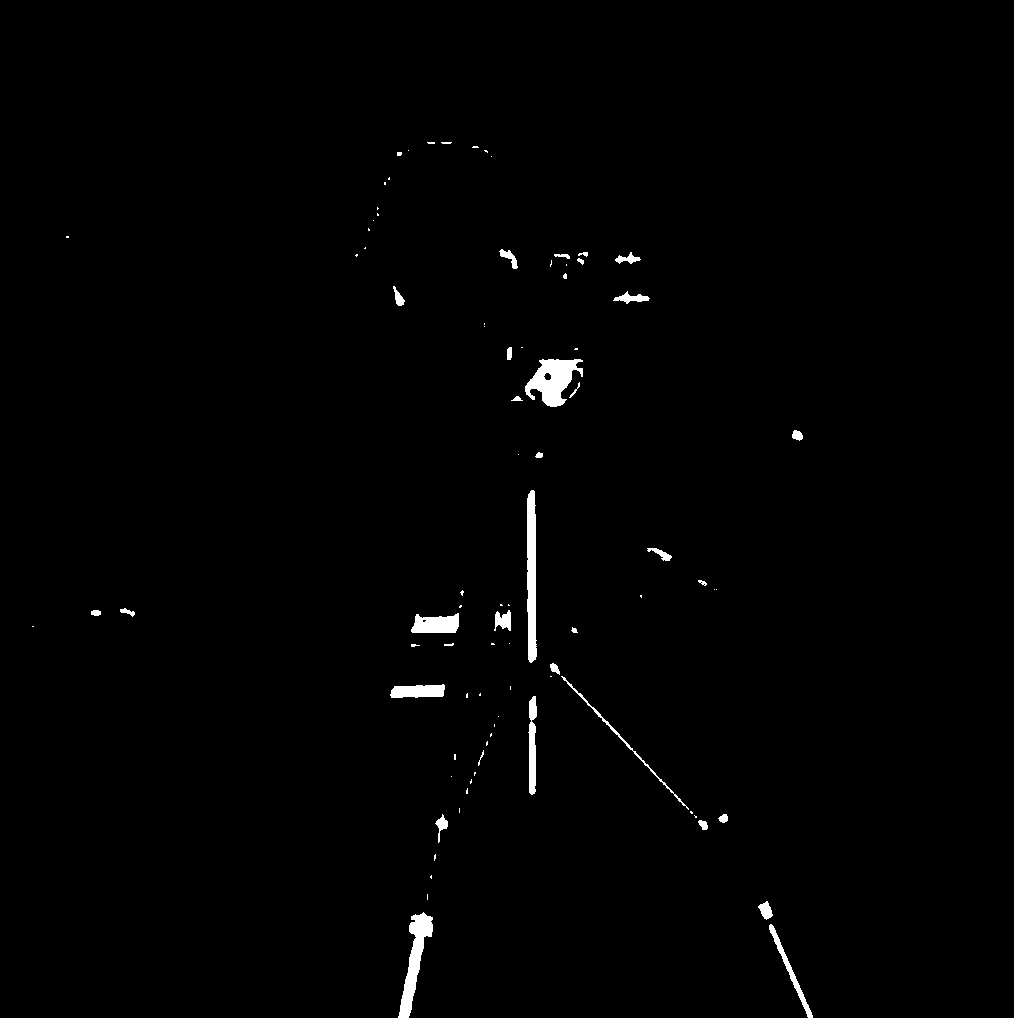

In [ ]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)

Original Image: 


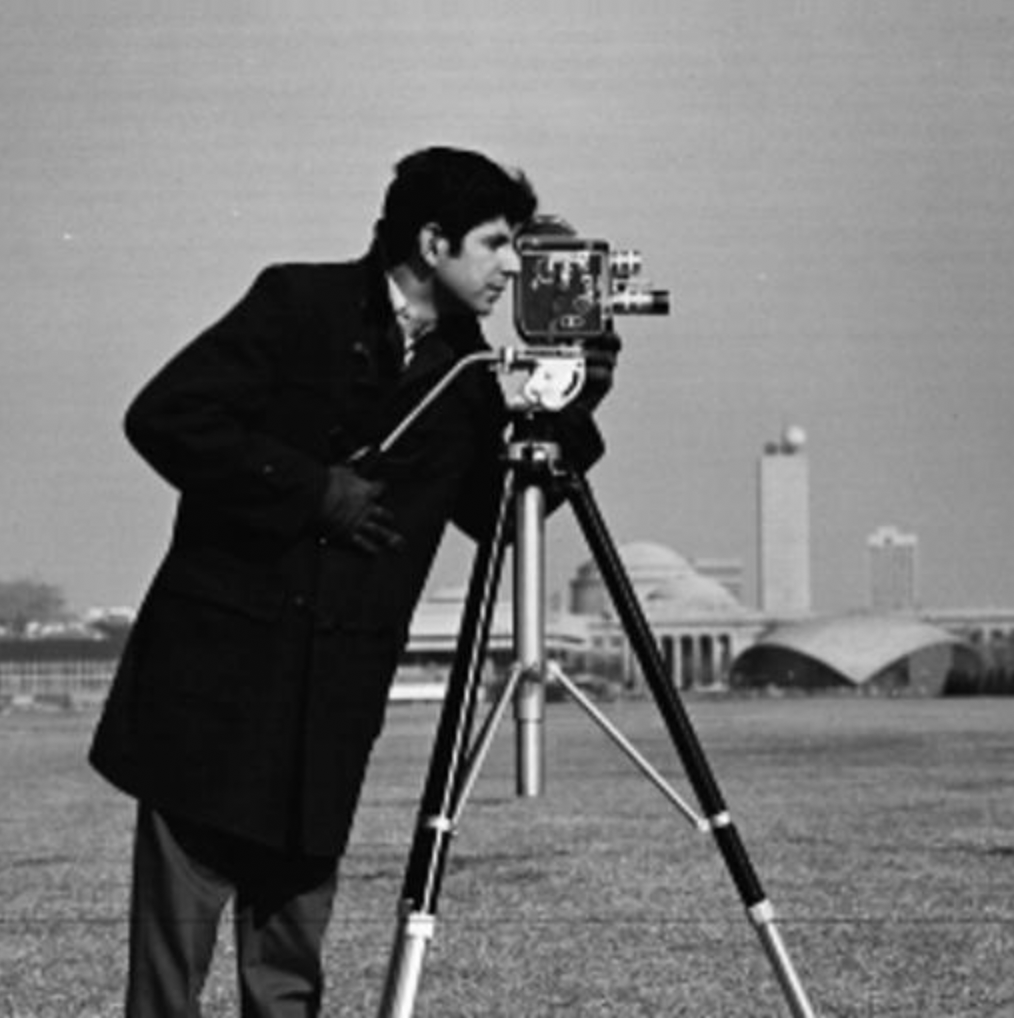

In [ ]:
print("Original Image: ")
cv2_imshow(img)

## Histograms

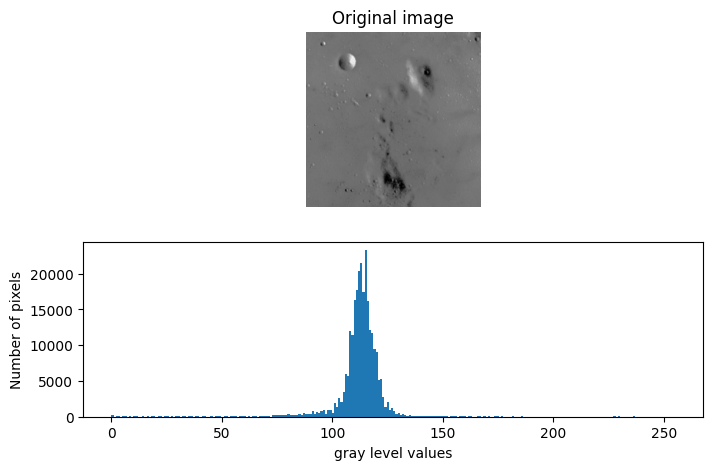

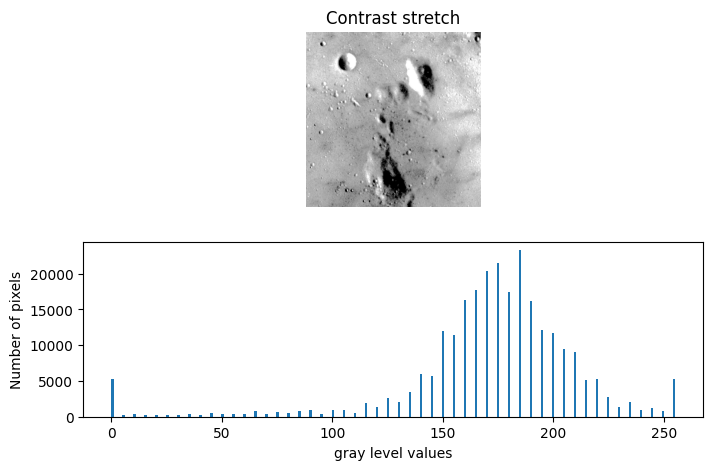

In [ ]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, exposure, img_as_float

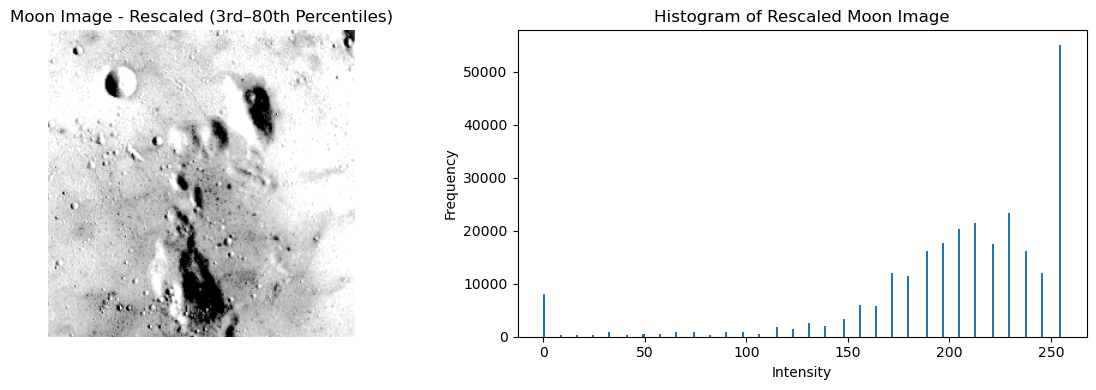

3rd percentile: 87.0
80th percentile: 118.0


In [2]:
# Task 1

moon = data.moon()

p3, p80 = np.percentile(moon, (3, 80))

moon_rescaled = exposure.rescale_intensity(
    moon,
    in_range=(p3, p80)
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].imshow(moon_rescaled, cmap='gray')
ax[0].set_title('Moon Image - Rescaled (3rd–80th Percentiles)')
ax[0].axis('off')

ax[1].hist(moon_rescaled.ravel(), bins=256)
ax[1].set_title('Histogram of Rescaled Moon Image')
ax[1].set_xlabel('Intensity')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("3rd percentile:", p3)
print("80th percentile:", p80)

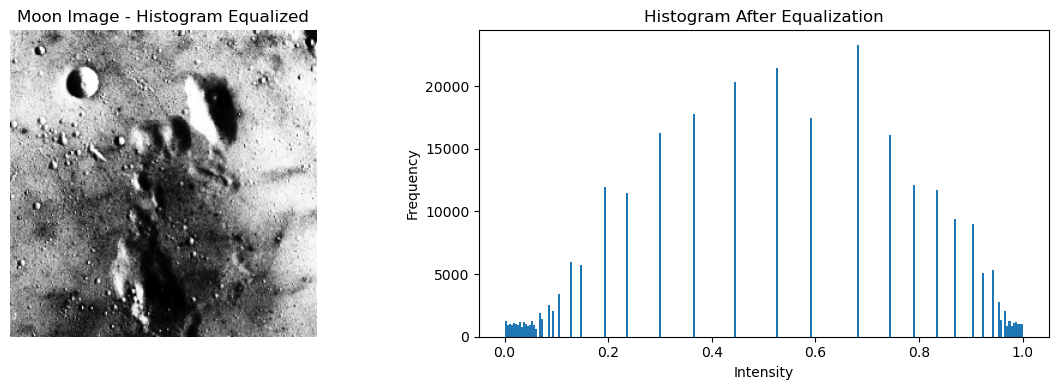

In [3]:
# Task 2

moon = data.moon()

moon_equalized = exposure.equalize_hist(moon)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].imshow(moon_equalized, cmap='gray')
ax[0].set_title('Moon Image - Histogram Equalized')
ax[0].axis('off')

ax[1].hist(moon_equalized.ravel(), bins=256)
ax[1].set_title('Histogram After Equalization')
ax[1].set_xlabel('Intensity')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

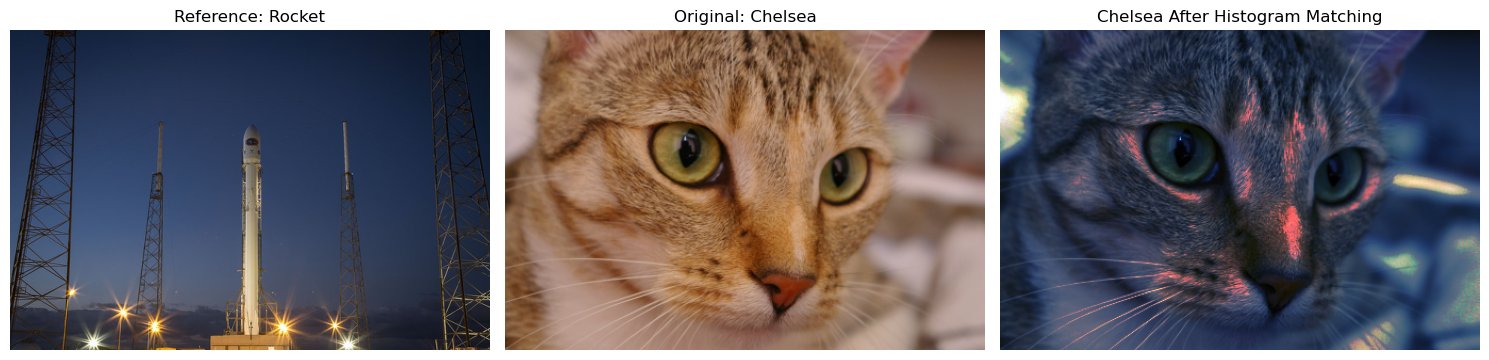

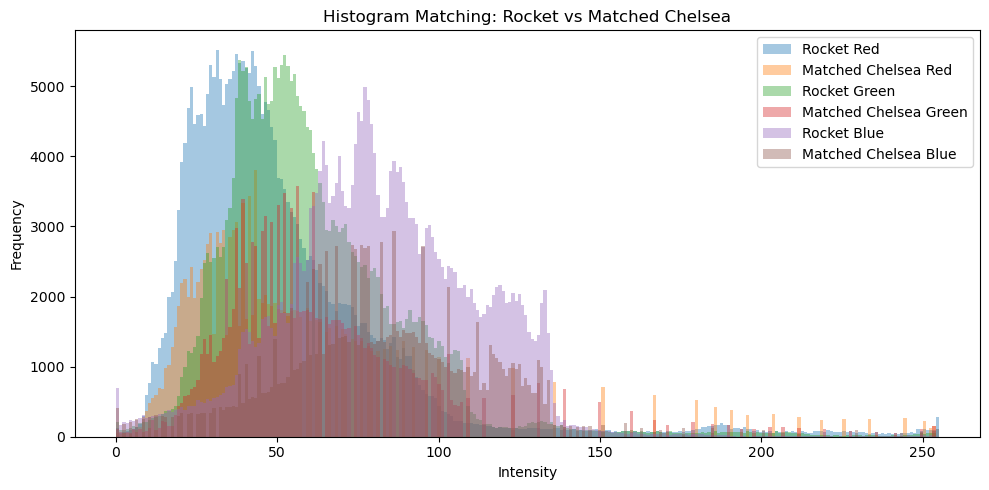

In [4]:
# Task 3

rocket = data.rocket()
chelsea = data.chelsea()

chelsea_matched = exposure.match_histograms(
    chelsea,
    rocket,
    channel_axis=-1
)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(rocket)
ax[0].set_title('Reference: Rocket')
ax[0].axis('off')

ax[1].imshow(chelsea)
ax[1].set_title('Original: Chelsea')
ax[1].axis('off')

ax[2].imshow(chelsea_matched)
ax[2].set_title('Chelsea After Histogram Matching')
ax[2].axis('off')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))

for channel, color, name in zip(
    range(3),
    ['r', 'g', 'b'],
    ['Red', 'Green', 'Blue']
):
    ax.hist(
        rocket[:, :, channel].ravel(),
        bins=256,
        alpha=0.4,
        label=f'Rocket {name}'
    )
    ax.hist(
        chelsea_matched[:, :, channel].ravel(),
        bins=256,
        alpha=0.4,
        label=f'Matched Chelsea {name}'
    )

ax.set_title('Histogram Matching: Rocket vs Matched Chelsea')
ax.set_xlabel('Intensity')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()